In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
%matplotlib inline

# Задание 1. Схема Кранка–Николсон для уравнения переноса

Задача: $u_t + au_x = f(t,x)$, $u(0,x)=\varphi(x)$, периодические ГУ.

Разностная схема:
$$\frac{y_k^{n+1}-y_k^n}{\tau}+\frac{a}{2}\left[\frac{y_{k+1}^{n+1}-y_{k-1}^{n+1}}{2h}+\frac{y_{k+1}^n-y_{k-1}^n}{2h}\right]=\frac{1}{2}(f_k^{n+1}+f_k^n)$$

**Аппроксимация:** разложением в ряд Тейлора — погрешность $O(\tau^2+h^2)$.

**Устойчивость** (метод Фурье, $f=0$): подставим $y_k^n=\lambda^n e^{imkh}$:
$$\lambda = \frac{1-i\sigma_m}{1+i\sigma_m},\quad \sigma_m=\frac{a\tau\sin(mh)}{2h}\implies|\lambda|=1 — \textbf{безусловно устойчива}$$

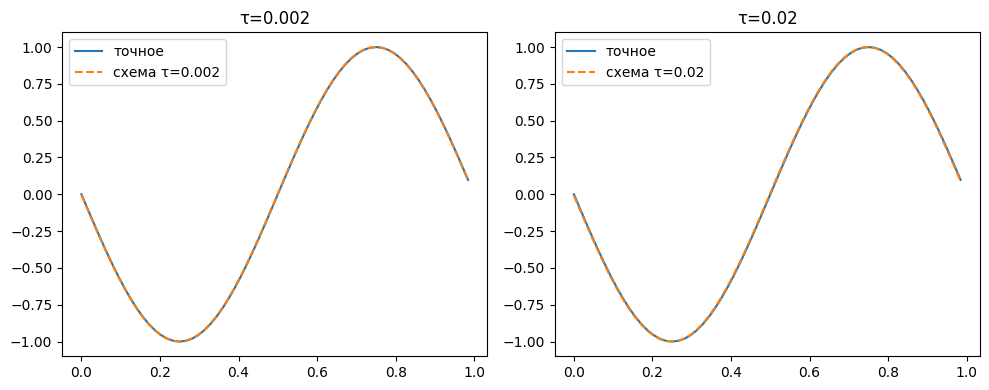

In [11]:
def transport_CN(a, phi, f, T, N, tau):
    h = 1.0/N; x = np.arange(N)*h; y = phi(x).copy()
    c = a*tau/(4*h)
    A = np.eye(N)
    for k in range(N):
        A[k,(k+1)%N] += c; A[k,(k-1)%N] -= c
    t = 0.0
    for _ in range(int(round(T/tau))):
        rhs = y - c*(np.roll(y,-1)-np.roll(y,1)) + tau/2*(f(t,x)+f(t+tau,x))
        y = np.linalg.solve(A, rhs); t += tau
    return x, y

a = 1.0
phi    = lambda x: np.sin(2*np.pi*x)
f_zero = lambda t, x: np.zeros_like(x)
u_ex   = lambda t, x: np.sin(2*np.pi*(x - a*t))
T = 0.5

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for tau, ax in zip([0.002, 0.02], axes):
    x, y = transport_CN(a, phi, f_zero, T, 64, tau)
    ax.plot(x, u_ex(T,x), label='точное')
    ax.plot(x, y, '--', label=f'схема τ={tau}')
    ax.set_title(f'τ={tau}'); ax.legend()
plt.tight_layout(); plt.show()

---
# Задание 2. Две схемы для уравнения теплопроводности

Задача: $u_t = a^2(x,t)u_{xx}$, $u(x,0)=\psi(x)$.

**Схема 1 — явная:** $\;y_k^{n+1}=y_k^n+\sigma(y_{k+1}^n-2y_k^n+y_{k-1}^n)$, $\sigma=a^2\tau/h^2$.

**Схема 2 — неявная (КН):** $\;(1+2r)y_k^{n+1}-r(y_{k+1}^{n+1}+y_{k-1}^{n+1})=y_k^n+r(y_{k+1}^n-2y_k^n+y_{k-1}^n)$, $r=\sigma/2$.

**Принцип замороженных коэффициентов** ($a^2=\mathrm{const}$):
$$\text{Схема 1: }\lambda=1-4\sigma\sin^2\tfrac{mh}{2}\text{ — устойч. при }\sigma\le\tfrac{1}{2}$$
$$\text{Схема 2: }\lambda=\frac{1-2r\cdot 4\sin^2\tfrac{mh}{2}}{1+2r\cdot 4\sin^2\tfrac{mh}{2}}\text{ — }|\lambda|\le1\text{ всегда}$$

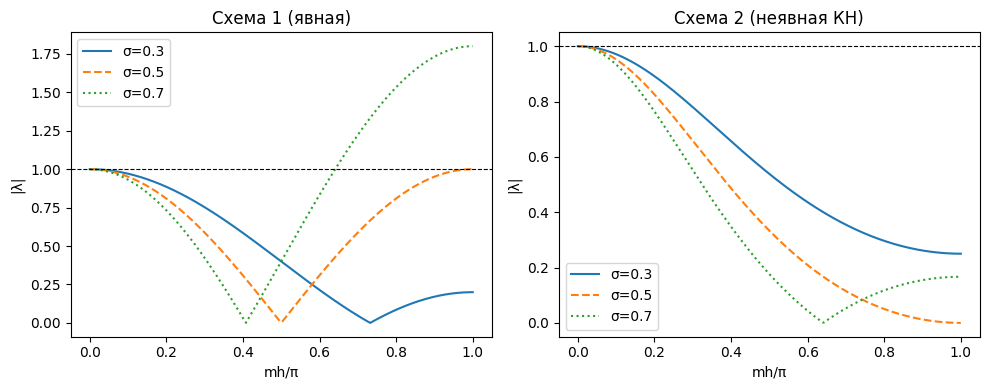

In [12]:
mh = np.linspace(0, np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for sigma, ls in zip([0.3, 0.5, 0.7], ['-','--',':']):
    s2 = np.sin(mh/2)**2
    axes[0].plot(mh/np.pi, np.abs(1-4*sigma*s2), ls=ls, label=f'σ={sigma}')
    axes[1].plot(mh/np.pi, np.abs((1-2*sigma*s2)/(1+2*sigma*s2)), ls=ls, label=f'σ={sigma}')
for ax, title in zip(axes, ['Схема 1 (явная)', 'Схема 2 (неявная КН)']):
    ax.axhline(1, color='k', lw=0.8, ls='--')
    ax.set_xlabel('mh/π'); ax.set_ylabel('|λ|'); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

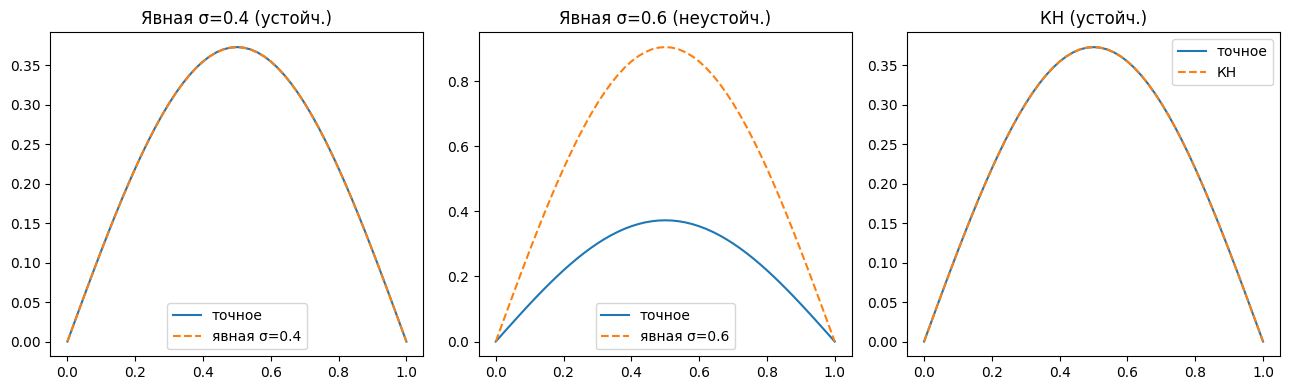

Явная σ=0.4: err=1.695e-04
КН:          err=4.640e-05


In [13]:
def heat_explicit(psi, T, N, tau):
    h=1.0/N; x=np.linspace(0,1,N+1); y=psi(x); y[0]=y[-1]=0.0
    for _ in range(int(round(T/tau))):
        y[1:-1] += tau/h**2*(y[2:]-2*y[1:-1]+y[:-2])
    return x, y

def heat_CN(psi, T, N, tau):
    h=1.0/N; x=np.linspace(0,1,N+1); y=psi(x); y[0]=y[-1]=0.0
    r=tau/(2*h**2); m=N-1
    lo=-r*np.ones(m); di=(1+2*r)*np.ones(m); up=-r*np.ones(m)
    ab=np.zeros((3,m)); ab[0,1:]=up[:-1]; ab[1]=di; ab[2,:-1]=lo[1:]
    for _ in range(int(round(T/tau))):
        rhs=y[1:-1]+r*(y[:-2]-2*y[1:-1]+y[2:])
        y[1:-1]=solve_banded((1,1),ab,rhs)
    return x, y

psi=lambda x: np.sin(np.pi*x); T=0.1
u_ex_heat=lambda x: np.exp(-np.pi**2*T)*np.sin(np.pi*x)
N=50; h=1.0/N

x1,y1_s=heat_explicit(psi,T,N,0.4*h**2)
x1,y1_u=heat_explicit(psi,0.01,N,0.6*h**2)
x2,y2=heat_CN(psi,T,N,0.005)

fig,axes=plt.subplots(1,3,figsize=(13,4))
axes[0].plot(x1,u_ex_heat(x1),label='точное'); axes[0].plot(x1,y1_s,'--',label='явная σ=0.4')
axes[0].set_title('Явная σ=0.4 (устойч.)'); axes[0].legend()
axes[1].plot(x1,u_ex_heat(x1),label='точное'); axes[1].plot(x1,y1_u,'--',label='явная σ=0.6')
axes[1].set_title('Явная σ=0.6 (неустойч.)'); axes[1].legend()
axes[2].plot(x2,u_ex_heat(x2),label='точное'); axes[2].plot(x2,y2,'--',label='КН')
axes[2].set_title('КН (устойч.)'); axes[2].legend()
plt.tight_layout(); plt.show()
print(f'Явная σ=0.4: err={np.max(np.abs(y1_s-u_ex_heat(x1))):.3e}')
print(f'КН:          err={np.max(np.abs(y2-u_ex_heat(x2))):.3e}')

---
# Задание 3. Метод переменных направлений (ADI)

$$u_t=u_{xx}+u_{yy}+f,\quad (x,y)\in[0,1]^2,\quad f=2\pi^2\sin(\pi x)\sin(\pi y)$$
$$u|_{\partial\Omega}=0,\quad u(x,y,0)=0,\quad u_{\rm точн}=(1-e^{-2\pi^2 t})\sin(\pi x)\sin(\pi y)$$

**Схема Писмена–Рэчфорда** (полушаг — неявно по $x$, явно по $y$; второй полушаг — наоборот):
$$\frac{u^*-u^n}{\tau/2}=\Lambda_x u^*+\Lambda_y u^n+f,\qquad\frac{u^{n+1}-u^*}{\tau/2}=\Lambda_x u^*+\Lambda_y u^{n+1}+f$$

Порядок: $O(\tau^2+h^2)$. Устойчивость — **безусловная**.

In [7]:
def tdma(lo, di, up, rhs):
    n=len(rhs); ab=np.zeros((3,n))
    ab[0,1:]=up[:-1]; ab[1]=di; ab[2,:-1]=lo[1:]
    return solve_banded((1,1),ab,rhs)

def run_adi(N, T, tau):
    h=1.0/N; x=np.linspace(0,1,N+1); y=np.linspace(0,1,N+1)
    X,Y=np.meshgrid(x,y,indexing='ij')
    u=np.zeros((N+1,N+1))
    f_arr=2*np.pi**2*np.sin(np.pi*X)*np.sin(np.pi*Y)
    r=tau/(2*h**2)
    lo=-r*np.ones(N-1); di=(1+2*r)*np.ones(N-1); up=-r*np.ones(N-1)
    for _ in range(int(round(T/tau))):
        u_star=np.zeros_like(u)
        for i in range(1,N):
            rhs=u[i,1:-1]+(tau/2)*(u[i,:-2]-2*u[i,1:-1]+u[i,2:])/h**2+(tau/2)*f_arr[i,1:-1]
            u_star[i,1:-1]=tdma(lo,di,up,rhs)
        u_new=np.zeros_like(u)
        for j in range(1,N):
            rhs=u_star[1:-1,j]+(tau/2)*(u_star[:-2,j]-2*u_star[1:-1,j]+u_star[2:,j])/h**2+(tau/2)*f_arr[1:-1,j]
            u_new[1:-1,j]=tdma(lo,di,up,rhs)
        u=u_new
    u_ex=(1-np.exp(-2*np.pi**2*T))*np.sin(np.pi*X)*np.sin(np.pi*Y)
    return np.max(np.abs(u-u_ex)), X, Y, u, u_ex

T=0.1; Ns=[8,16,32,64]; errs=[]
for N in Ns:
    tau=T/N
    err,*_=run_adi(N,T,tau)
    errs.append(err)
    print(f'N={N:3d}, τ={tau:.4f}: err={err:.3e}')
print('\nПорядок сходимости:')
for i in range(1,len(Ns)):
    p=np.log(errs[i-1]/errs[i])/np.log(Ns[i]/Ns[i-1])
    print(f'  N={Ns[i-1]}→{Ns[i]}: p={p:.2f}')

N=  8, τ=0.0125: err=7.903e-03
N= 16, τ=0.0063: err=1.973e-03
N= 32, τ=0.0031: err=4.932e-04
N= 64, τ=0.0016: err=1.233e-04

Порядок сходимости:
  N=8→16: p=2.00
  N=16→32: p=2.00
  N=32→64: p=2.00


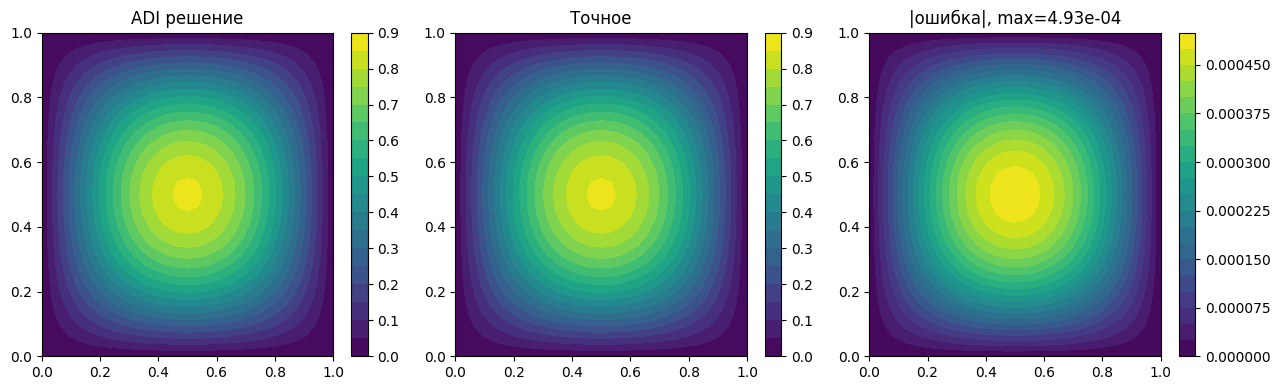

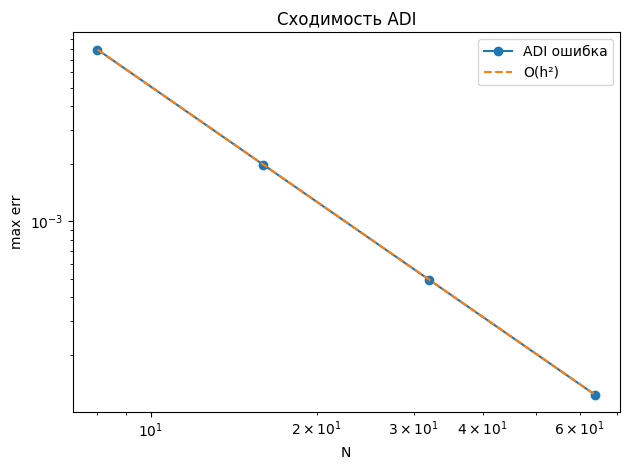

In [8]:
err,X,Y,u_sol,u_ex=run_adi(32,T,tau=T/32)

fig,axes=plt.subplots(1,3,figsize=(13,4))
c0=axes[0].contourf(X,Y,u_sol,levels=20); plt.colorbar(c0,ax=axes[0]); axes[0].set_title('ADI решение')
c1=axes[1].contourf(X,Y,u_ex,levels=20);  plt.colorbar(c1,ax=axes[1]); axes[1].set_title('Точное')
c2=axes[2].contourf(X,Y,np.abs(u_sol-u_ex),levels=20); plt.colorbar(c2,ax=axes[2])
axes[2].set_title(f'|ошибка|, max={err:.2e}')
plt.tight_layout(); plt.show()

plt.loglog(Ns,errs,'o-',label='ADI ошибка')
plt.loglog(Ns,[errs[0]*(Ns[0]/N)**2 for N in Ns],'--',label='O(h²)')
plt.xlabel('N'); plt.ylabel('max err'); plt.title('Сходимость ADI')
plt.legend(); plt.tight_layout(); plt.show()

**Вывод:** ADI безусловно устойчива, порядок $O(\tau^2+h^2)$, второй порядок подтверждён экспериментально.

---
# Задание 4. Нелинейное уравнение


Схема использует **стандартные центральные разности** для второй производной:

$$\frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h_x^2} + \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h_y^2} = 0$$

Разложение в ряд Тейлора даёт:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h_x^2} = \frac{\partial^2 u}{\partial x^2} + \frac{h_x^2}{12}\frac{\partial^4 u}{\partial x^4} + O(h_x^4)$$

Погрешность аппроксимации:

$$\psi = \frac{h_x^2}{12}\frac{\partial^4 u}{\partial x^4} + \frac{h_y^2}{12}\frac{\partial^4 u}{\partial y^4} + O(h^4)$$

**Порядок аппроксимации:** $O(h_x^2 + h_y^2)$

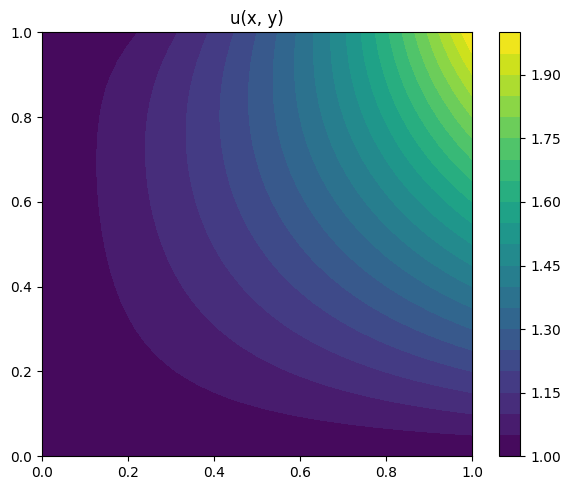

In [16]:
def solve_task4(Nx, Ny, X=1.0, Y=1.0):
    hx = X / Nx; hy = Y / Ny
    x = np.linspace(0, X, Nx + 1)
    y = np.linspace(0, Y, Ny + 1)
    XX, YY = np.meshgrid(x, y, indexing='ij')

    u = np.zeros((Nx + 1, Ny + 1))
    u[0,  :]  = 1.0                   # x = 0
    u[:,  0]  = 1.0                   # y = 0
    u[:, -1]  = 1 + x**2             # y = Y
    u[-1, :]  = 1 + X**2 * y / Y    # x = X

    m = (Nx - 1) * (Ny - 1)
    A = np.zeros((m, m)); b = np.zeros(m)
    rx = 1 / hx**2; ry = 1 / hy**2

    def idx(i, j): return (i - 1) * (Ny - 1) + (j - 1)

    for i in range(1, Nx):
        for j in range(1, Ny):
            k = idx(i, j)
            A[k, k] = -2*rx - 2*ry
            if i > 1:      A[k, idx(i-1, j)] = rx
            else:          b[k] -= rx * u[0,  j]
            if i < Nx - 1: A[k, idx(i+1, j)] = rx
            else:          b[k] -= rx * u[Nx, j]
            if j > 1:      A[k, idx(i, j-1)] = ry
            else:          b[k] -= ry * u[i,  0]
            if j < Ny - 1: A[k, idx(i, j+1)] = ry
            else:          b[k] -= ry * u[i,  Ny]

    u_in = np.linalg.solve(A, b)
    for i in range(1, Nx):
        for j in range(1, Ny):
            u[i, j] = u_in[idx(i, j)]

    return XX, YY, u


XX, YY, u = solve_task4(30, 30)

fig, ax = plt.subplots(figsize=(6, 5))
c = ax.contourf(XX, YY, u, levels=20)
plt.colorbar(c, ax=ax)
ax.set_title('u(x, y)')
plt.tight_layout()
plt.show()